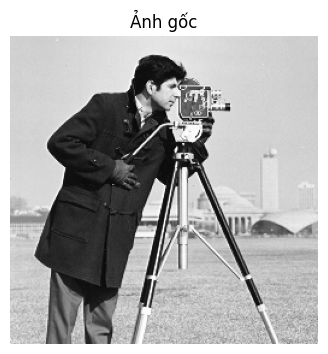

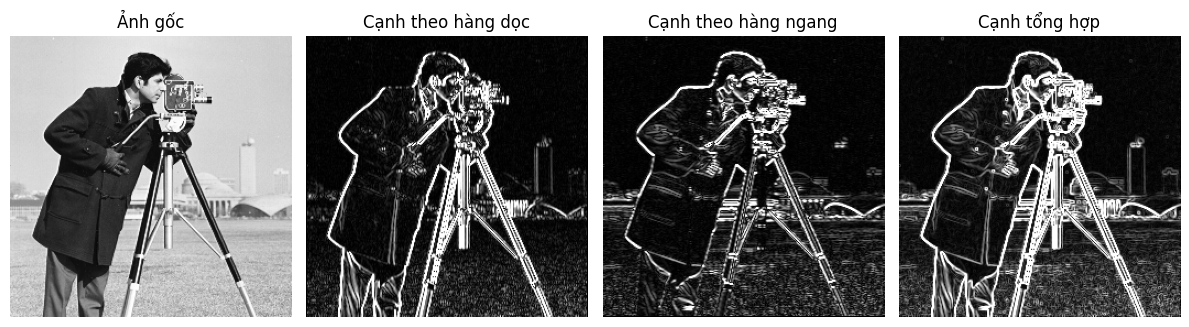

Kích thước ảnh gốc: (256, 256)
Kích thước Sx: (256, 256)
Kích thước Sy: (256, 256)
Kích thước ảnh biên tổng hợp: (256, 256)
Kiểm tra hoàn tất: các ảnh kết quả có cùng kích thước với ảnh gốc và có thể hiển thị được.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: PHÁT HIỆN BIÊN BẰNG TOÁN TỬ SOBEL
# Chương/Mục liên quan: Chương 4, Mục 4.1.4.4
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách phát hiện biên ảnh bằng toán tử Sobel.
# - Giúp người học quan sát biên theo phương x, phương y và biên tổng hợp.
# - Liên hệ phần code với phép tính gradient ảnh trong giáo trình.

# Sau khi chạy code, người học cần:
# 1. Hiểu được vai trò của đạo hàm theo hai phương x và y.
# 2. Quan sát được sự khác nhau giữa biên dọc, biên ngang và biên tổng hợp.
# 3. Biết thay đổi tham số của toán tử Sobel để kiểm tra ảnh hưởng đến kết quả.

# Input:
# - Dữ liệu đầu vào: ảnh cameraman từ GitHub
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh gốc
# - Ảnh biên theo phương x
# - Ảnh biên theo phương y
# - Ảnh biên tổng hợp

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_GRAYSCALE)


image_uri = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"

img = read_gitlab_image(image_uri)

if img is None:
    raise FileNotFoundError("Không tìm thấy file cameraman.png")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Tính đạo hàm xấp xỉ theo phương x bằng toán tử Sobel
# Dòng code này tương ứng với bước tính gradient ảnh theo phương x
Sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

# Tính đạo hàm xấp xỉ theo phương y bằng toán tử Sobel
# Dòng code này tương ứng với bước tính gradient ảnh theo phương y
Sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Chuyển giá trị gradient về dạng ảnh 8-bit để hiển thị
Ex = cv2.convertScaleAbs(Sx)
Ey = cv2.convertScaleAbs(Sy)

# Tính độ lớn gradient tổng hợp từ hai thành phần Sx và Sy
# Dòng code này tương ứng với công thức độ lớn gradient: E = sqrt(Sx^2 + Sy^2)
E = cv2.magnitude(Sx, Sy)
E = cv2.convertScaleAbs(E)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(Ex, cmap="gray")
plt.title("Cạnh theo hàng dọc")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(Ey, cmap="gray")
plt.title("Cạnh theo hàng ngang")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(E, cmap="gray")
plt.title("Cạnh tổng hợp")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Kích thước ảnh gốc:", img.shape)
print("Kích thước Sx:", Sx.shape)
print("Kích thước Sy:", Sy.shape)
print("Kích thước ảnh biên tổng hợp:", E.shape)

assert img.shape == Ex.shape == Ey.shape == E.shape
assert E.dtype == np.uint8

print("Kiểm tra hoàn tất: các ảnh kết quả có cùng kích thước với ảnh gốc và có thể hiển thị được.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi ksize=3 thành ksize=5 hoặc ksize=7 trong cv2.Sobel để quan sát ảnh hưởng của kích thước mặt nạ.
# 2. Thay đổi bậc đạo hàm trong cv2.Sobel, ví dụ dx=2, dy=0 hoặc dx=0, dy=2.
# 3. So sánh riêng Ex, Ey và E để hiểu vai trò của gradient theo từng phương.